In [21]:
import zipfile
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# Extract ZIP
zip_path = "/content/archive (21).zip"
extract_path = "brain_tumor_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

X = []
y = []

IMG_SIZE = 128

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):

            img_path = os.path.join(root, file)

            img = cv2.imread(img_path)

            if img is not None:

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                X.append(img)

                folder_name = os.path.basename(root).lower()

                if folder_name in ["yes", "tumor"]:
                    y.append(1)
                else:
                    y.append(0)

X = np.array(X, dtype='float32')
y = np.array(y)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Images Shape: (506, 128, 128, 3)
Labels Shape: (506,)


In [22]:
X = X / 255.0

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(404, 128, 128, 3)
(102, 128, 128, 3)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(128,128,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 708ms/step - accuracy: 0.6915 - loss: 0.6027 - val_accuracy: 0.8049 - val_loss: 0.4885
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 584ms/step - accuracy: 0.8044 - loss: 0.4838 - val_accuracy: 0.8537 - val_loss: 0.4462
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 607ms/step - accuracy: 0.8127 - loss: 0.4295 - val_accuracy: 0.8537 - val_loss: 0.4363
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 670ms/step - accuracy: 0.8595 - loss: 0.3503 - val_accuracy: 0.9268 - val_loss: 0.3271
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 655ms/step - accuracy: 0.9063 - loss: 0.2496 - val_accuracy: 0.8049 - val_loss: 0.3906
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 593ms/step - accuracy: 0.8926 - loss: 0.2416 - val_accuracy: 0.8780 - val_loss: 0.2663
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 659ms/step - accuracy: 0.9366 - loss: 0.1566 - val_accuracy: 0.9024 - val_loss: 0.2470
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 642ms/step - accuracy: 0.9559 - loss: 0.1269 - val_accuracy:

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step - accuracy: 1.0000 - loss: 0.0152
Test Accuracy: 1.0


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step


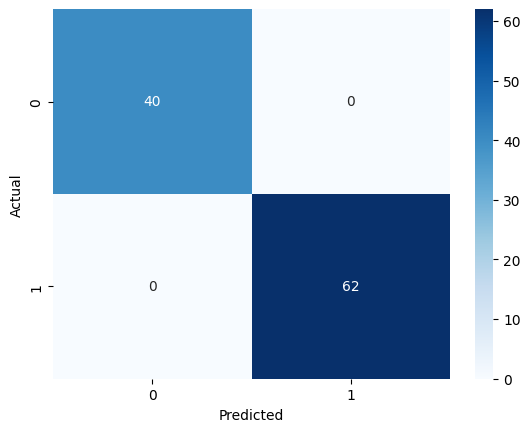

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

Saving 15 no.jpg to 15 no.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
No Brain Tumor


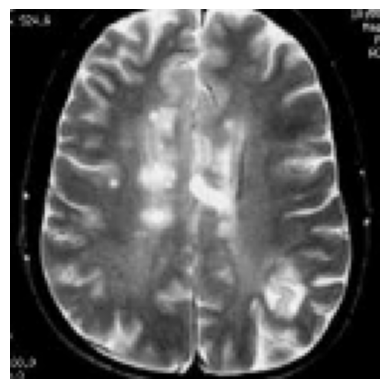

In [33]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (128,128))

img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor")
plt.imshow(img[0])
plt.axis("off")
plt.show()